In [27]:
# Import required libraries for deep learning and image processing
import os # For file path operations
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'  # Disable GPU, force CPU usage

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator  # For image preprocessing and augmentation
from tensorflow.keras import layers, models  # For building neural network layers
import matplotlib.pyplot as plt  # For plotting graphs and showing images
import numpy as np  # For numerical operations

print("Libraries imported successfully!")
print("TensorFlow version:", tf.__version__)

Libraries imported successfully!
TensorFlow version: 2.21.0


In [28]:
# Define the base directory containing our dataset
# 'data' folder contains train, validation, and test subfolders
base_dir = 'data'

# Create complete paths to each split folder
train_dir = os.path.join(base_dir, 'train')        # Training images
val_dir = os.path.join(base_dir, 'validation')    # Validation images (for tuning during training)
test_dir = os.path.join(base_dir, 'test')         # Test images (final evaluation only)

# Verify all required folders exist
print("Train folder exists:", os.path.exists(train_dir))
print("Validation folder exists:", os.path.exists(val_dir))
print("Test folder exists:", os.path.exists(test_dir))

# Display all animal classes found in training folder
print("\nYour animal classes:")
print(os.listdir(train_dir))

Train folder exists: True
Validation folder exists: True
Test folder exists: True

Your animal classes:
['tiger', 'gorila', 'crocodile', 'deer']


In [29]:
# Data augmentation for training set
# This creates variations of existing images to prevent overfitting
train_datagen = ImageDataGenerator(
    rescale=1./255,           # Normalize pixel values from [0,255] to [0,1] for better training
    rotation_range=20,        # Randomly rotate images by up to 20 degrees
    width_shift_range=0.2,    # Randomly shift images horizontally by up to 20%
    height_shift_range=0.2,   # Randomly shift images vertically by up to 20%
    horizontal_flip=True,     # Randomly mirror images horizontally
    zoom_range=0.2            # Randomly zoom in/out by up to 20%
)

# For validation and test sets - only normalize, no augmentation
# We don't augment validation/test because we want consistent evaluation
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Load training images from folders
# flow_from_directory automatically assigns labels based on folder names
train_generator = train_datagen.flow_from_directory(
    train_dir,                      # Directory containing class subfolders
    target_size=(224, 224),         # Resize all images to 224x224 (required by MobileNetV2)
    batch_size=32,                  # Process 32 images at a time
    class_mode='categorical'        # Multi-class classification (4 animals, mutually exclusive)
)

# Load validation images
val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

# Load test images
# shuffle=False is important for evaluation - we need to match predictions with true labels
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False                   # Don't shuffle test set for proper evaluation
)

# Display the mapping from folder names to class indices
# Example: {'deer': 0, 'crocodile': 1, 'tiger': 2, 'gorilla': 3}
print("\nClass mapping (folder name to number):")
print(train_generator.class_indices)

Found 90 images belonging to 4 classes.
Found 20 images belonging to 4 classes.
Found 22 images belonging to 4 classes.

Class mapping (folder name to number):
{'crocodile': 0, 'deer': 1, 'gorila': 2, 'tiger': 3}


In [30]:
# Load MobileNetV2 pre-trained on ImageNet dataset
# MobileNetV2 is a lightweight CNN architecture good for small datasets
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),    # Input image dimensions (height, width, channels)
    include_top=False,             # Remove the original classification head (trained on 1000 ImageNet classes)
    weights='imagenet'             # Load weights pre-trained on ImageNet
)

# FREEZE the base model layers
# This preserves the pre-trained knowledge (edges, textures, shapes)
# Only our new layers will be trained
base_model.trainable = False

# Build our custom model by adding new layers on top of the pre-trained base
model = models.Sequential([
    base_model,                                    # Pre-trained feature extractor
    layers.GlobalAveragePooling2D(),               # Reduces each feature map to a single value
    layers.Dense(128, activation='relu'),          # Hidden layer with 128 neurons, ReLU activation
    layers.Dropout(0.2),                           # Randomly drops 20% of neurons to prevent overfitting
    layers.Dense(4, activation='softmax')          # Output layer: 4 neurons (one per animal), softmax gives probabilities
])

# Compile the model with optimizer, loss function, and metrics
model.compile(
    optimizer='adam',                              # Adam optimizer (adaptive learning rate)
    loss='categorical_crossentropy',               # Loss function for multi-class classification
    metrics=['accuracy']                           # Track accuracy during training
)

# Display model architecture summary
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [31]:
# Train the model on our dataset
# Only the new layers we added will be trained (base model is frozen)
history = model.fit(
    train_generator,                               # Training data
    steps_per_epoch=train_generator.samples // train_generator.batch_size,  # Number of batches per epoch
    epochs=15,                                     # Train for 15 complete passes through the data
    validation_data=val_generator,                 # Validation data for monitoring
    validation_steps=val_generator.samples // val_generator.batch_size      # Number of validation batches
)

Epoch 1/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 18s 10s/step - accuracy: 0.2931 - loss: 1.8259 - val_accuracy: 0.5000 - val_loss: 1.0460
Epoch 2/15
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 783ms/step - accuracy: 0.5000 - loss: 1.1443

/home/badr/Projects/ImageClassification/myenv/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 3s/step - accuracy: 0.5000 - loss: 1.1443 - val_accuracy: 0.5500 - val_loss: 0.9909
Epoch 3/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 11s 7s/step - accuracy: 0.5781 - loss: 0.9669 - val_accuracy: 0.7000 - val_loss: 0.6845
Epoch 4/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.7692 - loss: 0.5660 - val_accuracy: 0.9000 - val_loss: 0.6043
Epoch 5/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 11s 7s/step - accuracy: 0.7812 - loss: 0.4960 - val_accuracy: 0.7500 - val_loss: 0.6397
Epoch 6/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.8077 - loss: 0.4878 - val_accuracy: 0.7500 - val_loss: 0.6691
Epoch 7/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 11s 7s/step - accuracy: 0.8966 - loss: 0.2927 - val_accuracy: 0.7500 - val_loss: 0.6517
Epoch 8/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 3s/step - accuracy: 0.7812 - loss: 0.4644 - val_accuracy: 0.8000 - val_loss: 0.5421
Epoch 9/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 12s 7s/step - accuracy: 0.9531 - loss: 0.2313 - val_accuracy: 0.9000 - val_loss: 0.3824
Epoch 10/15
2/2 ━━━━━━━

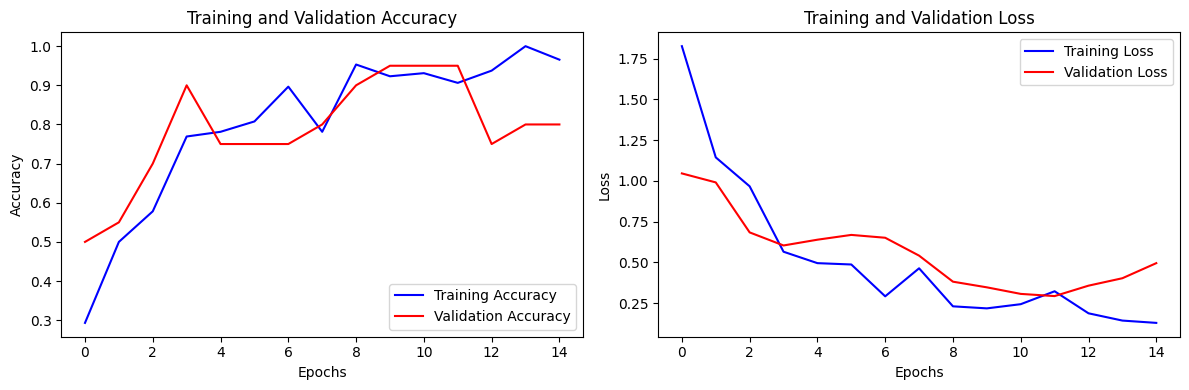

In [32]:
# Extract training history metrics
acc = history.history['accuracy']           # Training accuracy per epoch
val_acc = history.history['val_accuracy']   # Validation accuracy per epoch
loss = history.history['loss']              # Training loss per epoch
val_loss = history.history['val_loss']      # Validation loss per epoch

epochs_range = range(len(acc))              # X-axis: number of epochs

# Create figure with 2 subplots side by side
plt.figure(figsize=(12, 4))

# Subplot 1: Accuracy over time
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='blue')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='red')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

# Subplot 2: Loss over time
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='blue')
plt.plot(epochs_range, val_loss, label='Validation Loss', color='red')
plt.legend()
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.tight_layout()  # Adjust spacing between subplots
plt.show()

In [33]:
# Evaluate the trained model on the test set
# Test set contains images the model has NEVER seen during training or validation
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"\n=== Final Results ===")
print(f"Test Accuracy: {test_accuracy:.2f}")  # Percentage of correct predictions
print(f"Test Loss: {test_loss:.2f}")           # Lower is better

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.9091 - loss: 0.3945

=== Final Results ===
Test Accuracy: 0.91
Test Loss: 0.39


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


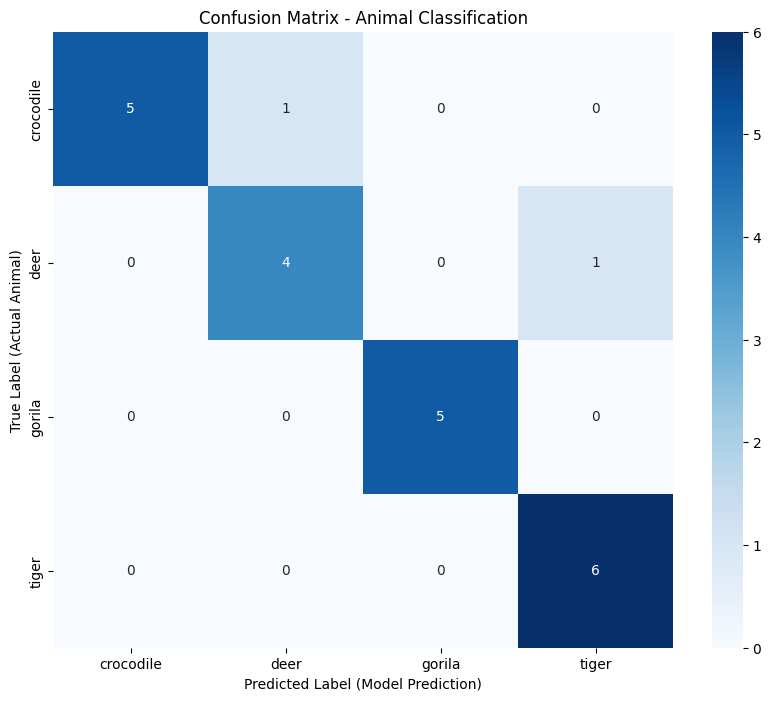


=== Misclassification Analysis ===
  crocodile was incorrectly predicted as deer: 1 time(s)
  deer was incorrectly predicted as tiger: 1 time(s)


In [34]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Reset test generator to start from beginning
test_generator.reset()

# Get predictions for all test images
predictions = model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)  # Get the class with highest probability

# Get true labels from test generator
true_classes = test_generator.classes

# Create confusion matrix
# Rows: True labels, Columns: Predicted labels
cm = confusion_matrix(true_classes, predicted_classes)

# Get class names for labeling the matrix
class_names = list(train_generator.class_indices.keys())

# Plot confusion matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names)
plt.title('Confusion Matrix - Animal Classification')
plt.ylabel('True Label (Actual Animal)')
plt.xlabel('Predicted Label (Model Prediction)')
plt.show()

# Print detailed misclassification analysis
print("\n=== Misclassification Analysis ===")
for i, true_name in enumerate(class_names):
    for j, pred_name in enumerate(class_names):
        if i != j and cm[i][j] > 0:
            print(f"  {true_name} was incorrectly predicted as {pred_name}: {cm[i][j]} time(s)")

In [35]:
# Get class names
class_names = list(train_generator.class_indices.keys())

# Print full confusion matrix with numbers
print("\n=== Full Confusion Matrix ===")
print("Rows: True Labels, Columns: Predicted Labels")
print("      " + "  ".join([f"{name[:4]:>6}" for name in class_names]))
for i, true_name in enumerate(class_names):
    row = f"{true_name[:8]:<8}"
    for j in range(len(class_names)):
        row += f"{cm[i][j]:>6}"
    print(row)

print("\n=== Per-Class Accuracy ===")
for i, name in enumerate(class_names):
    correct = cm[i][i]
    total = sum(cm[i][:])
    acc = correct/total * 100 if total > 0 else 0
    print(f"  {name}: {correct}/{total} correct ({acc:.1f}%)")


=== Full Confusion Matrix ===
Rows: True Labels, Columns: Predicted Labels
        croc    deer    gori    tige
crocodil     5     1     0     0
deer         0     4     0     1
gorila       0     0     5     0
tiger        0     0     0     6

=== Per-Class Accuracy ===
  crocodile: 5/6 correct (83.3%)
  deer: 4/5 correct (80.0%)
  gorila: 5/5 correct (100.0%)
  tiger: 6/6 correct (100.0%)
